# 1. 📚 Importar librerias

In [49]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from src.pipeline import run_pipeline

# 2. 📊 Cargar csv/df

In [93]:
'''
        En esta ocasion no es necesario aplicar un df.copy(), ya que la informacion viene de la lista y DF no 
        es una vista de la informacion, es un objeto nuevo.
'''
small_data = '../data/raw/2023-03-08 Precios Casas RM.csv'
large_data = '../data/raw/2023-07-18 Propiedades Web Scrape.csv' 

DTYPES = {
    'Price_UF': 'float32',
    'Built Area': 'float32',
    'Total Area': 'float32',
    'Baths': 'Int8',
    'Dorms': 'Int8',
    'Parking': 'Int8',
}

# Importamos el archivo csv a la variable df
lst = list() # Cremos una lista para guardar los chunks

for chunk in pd.read_csv(large_data, chunksize = 1000, dtype=DTYPES):
   lst.append(chunk) # Guardamos los chunks de datos en la lista

df = pd.concat(lst) # Optimizamos memoria y concatenamos toda la informacion fuera de loop en un mismo DF

#               ^^^^^^^^^^^^^^^^^^             -------------->                **************
# df = pd.concat(pd.read_csv(large_data, chunksize=1000, dtype=DTYPES)) # Equivalente implicito

display(df)

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,129884400,3600.0,158396.0,Lampa,AvenidaLaHacienda,3,2,68.0,221.0,1,7850612,Behouse
1,130000000,3603.0,158537.0,Buin,Villaseca,5,3,150.0,190.0,2,10081485,NaN
2,172998805,4795.0,210974.0,PuenteAlto,BarrioAustria,4,3,90.0,182.0,3,10257247,Bissac
3,135296250,3750.0,164995.0,Buin,ComercianteArmandoPérezCarrasco,3,2,85.0,175.0,1,20153043,Ambiento Propiedades
4,195000000,5405.0,237805.0,QuintaNormal,Hostos,3,3,130.0,402.0,1,16669338,Puntoinmobiliario.cl
...,...,...,...,...,...,...,...,...,...,...,...,...
9286,80000000,2217.0,97561.0,PuenteAlto,LasAvestruces0352,2,1,75.0,100.0,2,7817190,Margarita Leiva Catalan
9287,250000000,6929.0,304878.0,PuenteAlto,manuelrodriguez,4,2,196.0,750.0,<NA>,7650477,Margarita Leiva Catalan
9288,3788295000,105000.0,4619872.0,LasCondes,CaminoLasFlores/CaminoPiedraRoja,5,7,460.0,4925.0,8,6032811,Tsi Property
9289,577264000,16000.0,703980.0,LaPintana,LosCipreses/LosDuraznos,4,2,311.0,2011.0,1,5314376,Tsi Property


In [52]:
print('Auditoria del dataset')
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')

checksum = pd.util.hash_pandas_object(df).sum()
print(f'Checksum: {checksum}\n')
assert checksum == 6967598655389734987, 'El archivo fuente cambio'

nulos = df.isnull().sum()
print('Valores nulos:')
display(nulos[nulos > 0])
print(f'Duplicados: {df.duplicated().sum()}\n')

# Validacion de esquema
ESQUEMA = {
    'Price_UF':   'float32',
    'Built Area': 'float32',
    'Dorms':      'Int8',
    'Baths':      'Int8',
    'Parking':    'Int8',
    'Comuna':     'object',
}

print('Validacion de esquema\n')
errores = []
for col, tipo in ESQUEMA.items():
    tipo_cargado = str(df[col].dtype)
    estado = True if tipo_cargado == tipo else False 
    if estado == False:
        errores.append(col)
    print(f'{estado} {col}: esperado={tipo_cargado}, real={tipo}')

if errores:
    print(f'Columnas con tipo incorrecto: {errores}')
else:
    print('Esquema validado correctamnete')

Auditoria del dataset
Filas:    9,291
Columnas: 12
Checksum: 6967598655389734987

Valores nulos:


Dorms           89
Baths          153
Built Area     278
Total Area     234
Parking       2920
Realtor       1166
dtype: int64

Duplicados: 0

Validacion de esquema

True Price_UF: esperado=float32, real=float32
True Built Area: esperado=float32, real=float32
True Dorms: esperado=Int8, real=Int8
True Baths: esperado=Int8, real=Int8
True Parking: esperado=Int8, real=Int8
True Comuna: esperado=object, real=object
Esquema validado correctamnete


# 3. 🔬 EDA
Comenzamos un EDA

In [53]:
display(df.info(),df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9291 entries, 0 to 9290
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price_CLP   9291 non-null   int64  
 1   Price_UF    9291 non-null   float32
 2   Price_USD   9291 non-null   float64
 3   Comuna      9291 non-null   object 
 4   Ubicacion   9291 non-null   object 
 5   Dorms       9202 non-null   Int8   
 6   Baths       9138 non-null   Int8   
 7   Built Area  9013 non-null   float32
 8   Total Area  9057 non-null   float32
 9   Parking     6371 non-null   Int8   
 10  id          9291 non-null   int64  
 11  Realtor     8125 non-null   object 
dtypes: Int8(3), float32(3), float64(1), int64(2), object(3)
memory usage: 599.0+ KB


None

(9291, 12)

El dataset contiene 9291 entradas, sin embargo hay variables que contienen menos datos, lo que nos indica que hay valores nulos

In [54]:
df.isnull().sum()

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms           89
Baths          153
Built Area     278
Total Area     234
Parking       2920
id               0
Realtor       1166
dtype: int64

In [55]:
cols = ['Baths', 'Built Area', 'Total Area', 'Parking', 'Realtor', 'Dorms']
for col in cols:
    print(f'% de datos que son nulos para "{col}": { ( ( df[col].isnull().sum() / df.shape[0] ) * 100 ).round(2) }%')

% de datos que son nulos para "Baths": 1.65%
% de datos que son nulos para "Built Area": 2.99%
% de datos que son nulos para "Total Area": 2.52%
% de datos que son nulos para "Parking": 31.43%
% de datos que son nulos para "Realtor": 12.55%
% de datos que son nulos para "Dorms": 0.96%


In [56]:
df.columns

Index(['Price_CLP', 'Price_UF', 'Price_USD', 'Comuna', 'Ubicacion', 'Dorms',
       'Baths', 'Built Area', 'Total Area', 'Parking', 'id', 'Realtor'],
      dtype='object')

In [57]:
df.describe().style.format('{:,.2f}')

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,"9,291.00","9,291.00","9,291.00","9,202.00","9,138.00","9,013.00","9,057.00","6,371.00","9,291.00"
mean,"392,513,379.71","10,879.28","478,674.86",4.03,2.75,"6,091.60",890.98,2.68,"14,111,574.63"
std,"403,651,502.95","11,187.99","492,257.92",1.66,1.48,"527,436.69","11,291.40",2.22,"4,187,239.01"
min,"37,000,000.00","1,026.00","45,122.00",1.00,1.00,1.00,1.00,1.00,"1,213,620.00"
25%,"128,206,726.50","3,553.50","156,350.00",3.00,2.00,90.00,134.00,1.00,"11,087,459.00"
50%,"234,513,500.00","6,500.00","285,992.00",4.00,3.00,131.00,230.00,2.00,"14,436,826.00"
75%,"526,753,400.00","14,600.00","642,382.00",5.00,3.00,209.00,480.00,3.00,"17,844,280.00"
max,"4,870,665,000.00","135,000.00","5,939,835.00",35.00,29.00,"50,000,000.00","720,000.00",26.00,"20,161,463.00"


# 4. ☣️ Limpieza datos 

In [58]:
df_clean = run_pipeline(df, False)

# 5. 🕶️ Analisis

In [59]:
df_clean.head()

,Price_UF,Comuna,Dorms,Baths,Built Area,Total Area,Parking,Realtor,UF_m2
0,3600.0,Lampa,3,2,68.0,221.0,1,Behouse,52.941177
1,3603.0,Buin,5,3,150.0,190.0,2,Desconocido,24.020000
2,4795.0,PuenteAlto,4,3,90.0,182.0,3,Bissac,53.277779
3,3750.0,Buin,3,2,85.0,175.0,1,Ambiento Propiedades,44.117645
4,5405.0,QuintaNormal,3,3,130.0,402.0,1,Puntoinmobiliario.cl,41.576923


Text(0, 0.5, 'Casas')

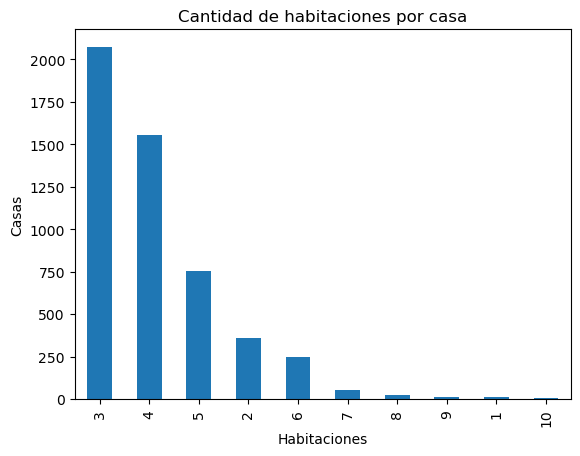

In [60]:
#plt.style.use('ggplot') #fivethirtyeight
ax = df_clean['Dorms'].value_counts().head(10)\
    .plot(kind='bar', 
          title='Cantidad de habitaciones por casa')
ax.set_xlabel('Habitaciones')
ax.set_ylabel('Casas')

Text(0, 0.5, 'Comuna')

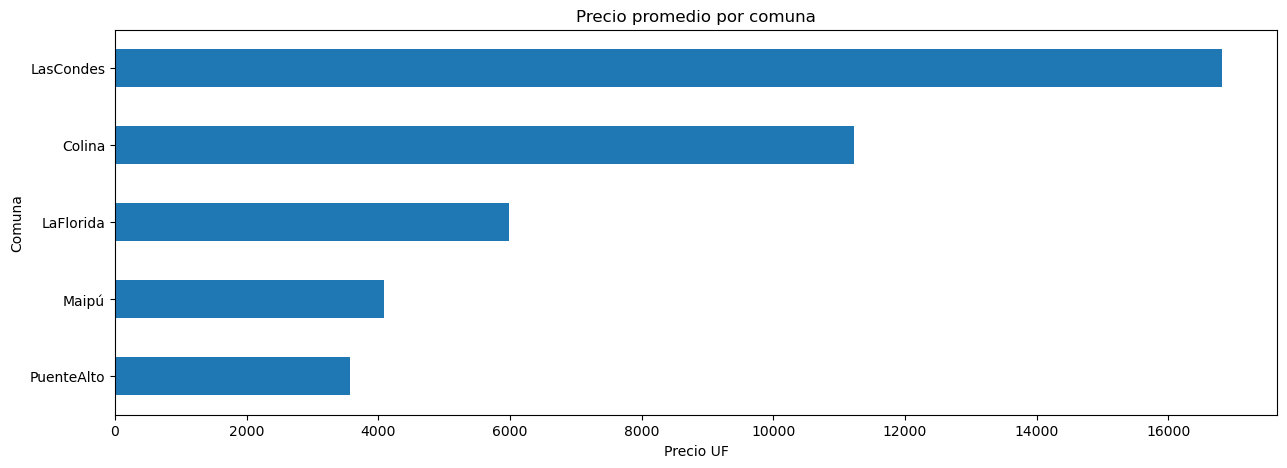

In [61]:
bx = df_clean.groupby('Comuna')['Price_UF'] \
    .agg(['mean', 'count']) \
    .query('count >= 250') \
    .sort_values('mean')['mean'] \
    .plot(kind='barh',
          figsize=(15,5),
          title='Precio promedio por comuna')
bx.set_xlabel('Precio UF')
bx.set_ylabel('Comuna')

Text(0, 0.5, 'Comuna')

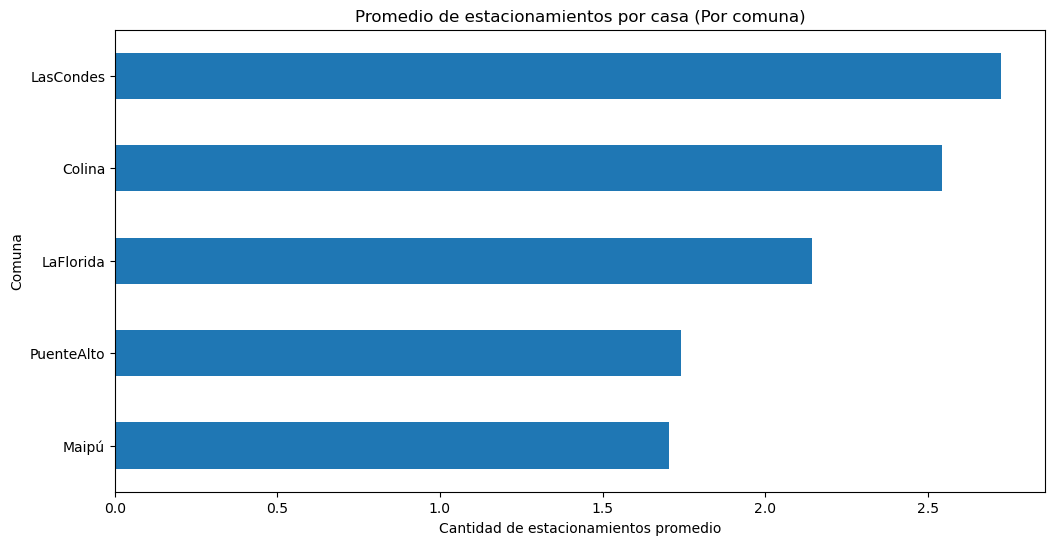

In [62]:
cx = (
    df_clean
    .groupby('Comuna')['Parking'] # Agrupa por comuna y selecciona solo la columna Parking para los valores
    .agg(['mean', 'count'])
    .query('count >= 250')
    .sort_values('mean')['mean'] # Ordena y se queda solo con 'mean' para graficar
    .plot(
        kind='barh',
        figsize=(12,6),
        title='Promedio de estacionamientos por casa (Por comuna)'
    )
)

cx.set_xlabel('Cantidad de estacionamientos promedio')
cx.set_ylabel('Comuna')

Text(0, 0.5, 'Comuna')

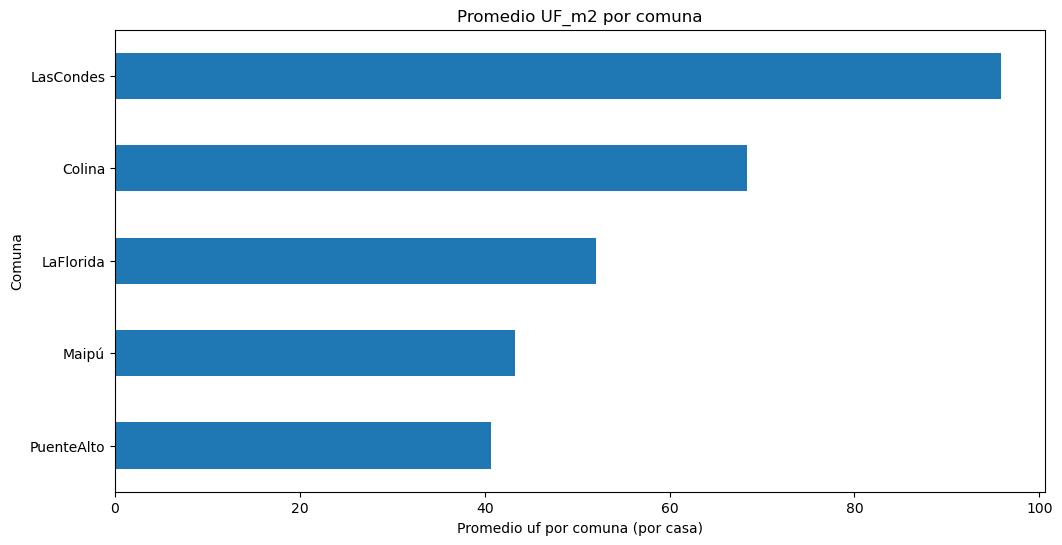

In [63]:
df_clean['UF_m2'] = (df_clean['Price_UF'] / df_clean['Built Area'])

dx = df_clean.groupby('Comuna')['UF_m2'] \
    .agg(['mean','count']) \
    .query('count > 250') \
    .sort_values('mean')['mean'] \
    .plot(
        kind='barh',
        figsize=(12,6),
        title='Promedio UF_m2 por comuna'
    )

dx.set_xlabel('Promedio uf por comuna (por casa)')
dx.set_ylabel('Comuna')

In [64]:
#corr = df_clean.drop(columns=['Comuna','id','Ubicacion','Realtor','Price_CLP','Price_USD']).corr()
corr = df_clean.select_dtypes('number').corr()
display(corr)

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking,UF_m2
Price_UF,1.000000,0.394306,0.663225,0.770527,0.778763,0.416056,0.779989
Dorms,0.394306,1.000000,0.504791,0.555276,0.382310,0.235753,0.116180
Baths,0.663225,0.504791,1.000000,0.647599,0.545302,0.300586,0.432542
Built Area,0.770527,0.555276,0.647599,1.000000,0.721181,0.395364,0.279626
Total Area,0.778763,0.382310,0.545302,0.721181,1.000000,0.485530,0.517011
Parking,0.416056,0.235753,0.300586,0.395364,0.485530,1.000000,0.300784
UF_m2,0.779989,0.116180,0.432542,0.279626,0.517011,0.300784,1.000000


<Axes: >

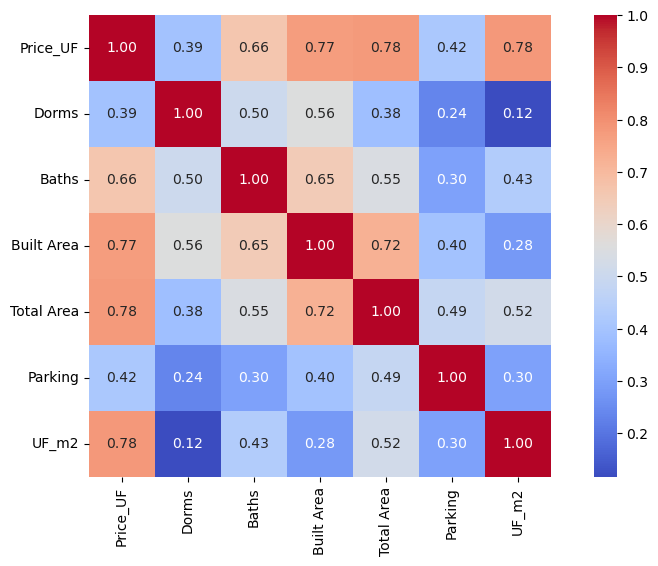

In [65]:
plt.figure(figsize=(11,6))
sns.heatmap(corr,
            cmap='coolwarm',
            square=True,
            fmt='.2f',
            annot=True)

In [66]:
df_clean['log_price'] = np.log(df_clean['Price_UF'])
df_clean['log_area'] = np.log(df_clean['Total Area'])
display(df_clean[['Price_UF','Total Area']].corr())
display(df_clean[['log_price','Total Area']].corr())
display(df_clean[['log_price','log_area']].corr())

,Price_UF,Total Area
Price_UF,1.000000,0.778763
Total Area,0.778763,1.000000


,log_price,Total Area
log_price,1.00000,0.75498
Total Area,0.75498,1.00000


,log_price,log_area
log_price,1.000000,0.812158
log_area,0.812158,1.000000


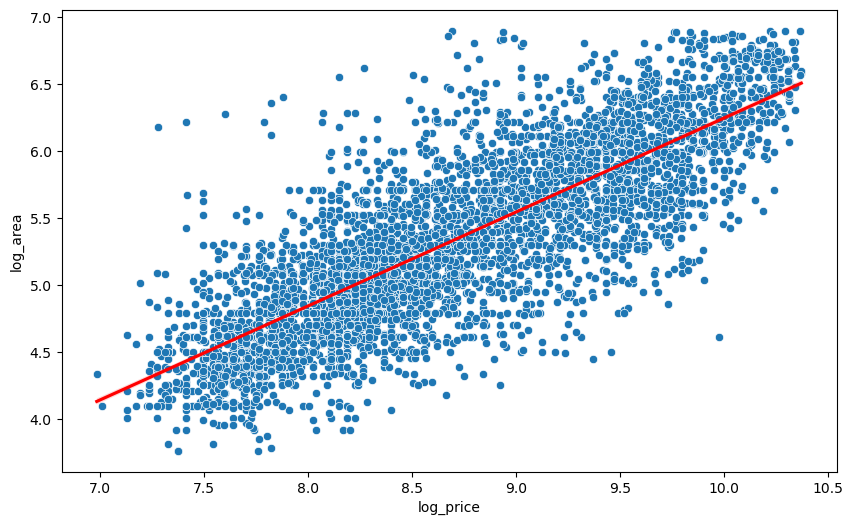

In [67]:
# Crear grafico de dispersion
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='log_price', y='log_area')

# Agregar linea de regresion
sns.regplot(data=df_clean, x='log_price', y='log_area', scatter=False, color='red')

plt.show()

In [68]:
df_clean.to_csv('../data/processed/casas_chile_limpio.csv', index=False)

In [69]:
resumen = (
    df_clean
    .groupby(['Comuna', 'Dorms'])
    .agg(
        precio_promedio=('Price_UF', 'mean'),
        precio_mediano=('Price_UF', 'median'),
        superficie_prom=('Built Area', 'mean'),
        uf_m2_prom=('UF_m2', 'mean'),
        cantidad=('Price_UF', 'count'),
    )
    .query('cantidad >= 30')           
    .sort_values(['Comuna', 'precio_promedio'], ascending=[True, False])
    .round(2)
)

umbral = 0.2
promedio_global = df_clean.groupby('Comuna')['UF_m2'].transform('mean') * umbral

df_clean['es_barata'] = (df_clean['UF_m2'] < promedio_global)

baratas = (
    df_clean
    .groupby(['Comuna'])
    .agg(
        promedio_comuna=('Price_UF', 'mean'),
        uf_m2_prom=('UF_m2','mean'),
        cantidad =('Price_UF', 'count'),
        casas_baratas=('es_barata', 'sum'),
        umbral = ('UF_m2', lambda x: x.mean() * umbral)
    )
    .query('cantidad >= 30')
    .sort_values('uf_m2_prom', ascending=False)
)

display(resumen)
display(df_clean[df_clean['UF_m2'] < promedio_global])
display(baratas)
#df_clean.drop(columns=['es_barata'], inplace=True)

precio_promedio  precio_mediano  superficie_prom  \
Comuna          Dorms                                                     
Buin            3          4723.540039          4500.0        93.070000   
Colina          5         14606.759766         13940.0       212.520004   
                4         12322.320312         12600.0       173.259995   
                3          9611.469727          9985.0       134.630005   
EstaciónCentral 3          4253.669922          3864.0       104.599998   
Huechuraba      4          8327.849609          7520.0       147.880005   
                3          6252.970215          6045.0       105.089996   
LaFlorida       5          7626.839844          7303.0       153.110001   
                4          6446.520020          6099.0       123.669998   
                3          5390.419922          4825.0       105.290001   
LaReina         5         15976.679688         14700.0       195.630005   
                4         14712.469727         13500.0       170.899994   
                3         11614.849609         11740.0       132.380005   
Lampa           3          4014.320068          3850.0        86.779999   
LasCondes       6         19541.179688         19000.0       233.119995   
                5         19523.619141         19500.0       217.160004   
                4         16295.940430         15500.0       174.320007   
                3         13851.209961         13390.0       136.100006   
LoBarnechea     4         21198.480469         21000.0       220.369995   
                5         20552.099609         19900.0       216.119995   
Maipú           5          5092.680176          4393.5       128.520004   
                4          4317.240234          3908.0       112.599998   
                3          3964.820068          3714.0        86.089996   
                2          2857.979980          2661.0        73.339996   
PadreHurtado    3          3935.100098          3300.0        91.779999   
Peñaflor        3          3718.939941          4075.0        89.690002   
Peñalolén       5         11141.690430         10995.0       168.110001   
                4          9102.559570          8900.0       144.000000   
                3          8570.019531          8500.0       124.820000   
Providencia     4         16039.809570         14950.0       177.190002   
Pudahuel        4          5994.359863          6236.5       123.139999   
                3          5938.259766          6075.0       112.209999   
PuenteAlto      5          4597.640137          4367.5       131.529999   
                4          4054.469971          3880.0       101.360001   
                3          3512.310059          3450.0        85.690002   
                2          2340.370117          2189.0        67.629997   
Quilicura       4          4190.930176          4158.0        99.230003   
                3          4036.620117          3900.0        87.400002   
SanBernardo     3          3552.209961          3298.0        88.750000   
                4          3514.629883          3093.0       104.610001   
                2          2138.280029          2058.0        58.779999   
Vitacura        4         18132.210938         17900.0       180.229996   
                3         15736.440430         14550.0       122.809998   
Ñuñoa           4         10758.110352          9000.0       155.960007   
                3          9412.580078          9474.5       119.099998   

                       uf_m2_prom  cantidad  
Comuna          Dorms                        
Buin            3       50.799999        72  
Colina          5       68.400002        46  
                4       70.610001       117  
                3       68.870003       168  
EstaciónCentral 3       43.720001        30  
Huechuraba      4       57.169998        40  
                3       59.320000        34  
LaFlorida       5       50.090000        37  
                4       52.529999    

,Price_UF,Comuna,Dorms,Baths,Built Area,Total Area,Parking,Realtor,UF_m2,log_price,log_area,es_barata
1562,1450.0,Colina,3,4,139.0,480.0,2,Mi Llave,10.431655,7.279319,6.173786,True
1966,1524.0,Colina,4,1,117.0,85.0,1,Desconocido,13.025641,7.329094,4.442651,True
2261,1926.0,Colina,5,2,168.0,108.0,1,Patricio Gajardo propiedades,11.464286,7.563200,4.682131,True
2295,2162.0,Colina,11,4,184.0,184.0,3,Agente Propiedades,11.750000,7.678789,5.214936,True


,promedio_comuna,uf_m2_prom,cantidad,casas_baratas,umbral
Comuna,,,,,
Vitacura,18004.785156,111.054001,126,0,22.210800
LasCondes,16814.273438,95.806549,501,0,19.161308
LoBarnechea,20529.515625,94.645004,182,0,18.929001
Providencia,16948.220703,88.293068,91,0,17.658613
LaReina,14240.813477,84.727325,198,0,16.945467
Ñuñoa,11369.294922,75.037689,163,0,15.007538
Colina,11228.120117,68.408569,350,4,13.681714
Peñalolén,9819.901367,65.718254,234,0,13.143651
Huechuraba,7884.147461,59.307232,95,0,11.861447


In [70]:
# Tabla 1: Resumen por comuna
resumen_comuna = (
    df_clean
    .groupby('Comuna')
    .agg(
        precio_promedio = ('Price_UF', 'mean'),
        uf_m2_promedio = ('UF_m2', 'mean'),
        total_propiedades = ('Price_UF', 'count')
    )
    .reset_index()
)

# Tabla 2: Comunas premium
premium = (
    df_clean
    .groupby('Comuna')
    .agg(
        precio_maximo=('Price_UF','max'),
        superficie_maxima=('Total Area','max'),
    )
    .reset_index()
)

# Join entre columnas
analisis_comunas = pd.merge(
    resumen_comuna,             # Left
    premium,                    # Right
    how = 'inner',              # Tipo de join, inner, outer, left, right
    on = 'Comuna',              # Sobre que columna se va a realizar
).sort_values('precio_promedio', ascending=False)

display(analisis_comunas)

,Comuna,precio_promedio,uf_m2_promedio,total_propiedades,precio_maximo,superficie_maxima
20,LoBarnechea,20529.515625,94.645004,182,31900.0,988.0
47,Vitacura,18004.785156,111.054001,126,29774.0,650.0
32,Providencia,16948.220703,88.293068,91,29000.0,890.0
19,LasCondes,16814.273438,95.806549,501,31700.0,986.0
17,LaReina,14240.813477,84.727325,198,31000.0,980.0
48,Ñuñoa,11369.294922,75.037689,163,30000.0,784.0
4,Colina,11228.120117,68.408569,350,26500.0,980.0
30,Peñalolén,9819.901367,65.718254,234,19999.0,920.0
42,SanMiguel,8427.348633,56.906712,66,22320.0,836.0
10,Huechuraba,7884.147461,59.307232,95,22000.0,805.0


In [71]:
analisis_comunas = (
    df_clean.
    groupby('Comuna')
    .agg(
        precio_promedio = ('Price_UF','mean'),
        uf_m2_promedio = ('UF_m2', 'mean'),
        total_propiedades = ('Price_UF', 'count'),
        precio_maximo = ('Price_UF', 'max'),
        superficie_maxima = ('Total Area', 'max'),
    )
    .query('total_propiedades > 30')
    .sort_values('precio_promedio', ascending = False)
    .reset_index()
)
analisis_comunas

,Comuna,precio_promedio,uf_m2_promedio,total_propiedades,precio_maximo,superficie_maxima
0,LoBarnechea,20529.515625,94.645004,182,31900.0,988.0
1,Vitacura,18004.785156,111.054001,126,29774.0,650.0
2,Providencia,16948.220703,88.293068,91,29000.0,890.0
3,LasCondes,16814.273438,95.806549,501,31700.0,986.0
4,LaReina,14240.813477,84.727325,198,31000.0,980.0
5,Ñuñoa,11369.294922,75.037689,163,30000.0,784.0
6,Colina,11228.120117,68.408569,350,26500.0,980.0
7,Peñalolén,9819.901367,65.718254,234,19999.0,920.0
8,SanMiguel,8427.348633,56.906712,66,22320.0,836.0
9,Huechuraba,7884.147461,59.307232,95,22000.0,805.0


In [ ]:
df_clean['Price_UF_millones'] = df_clean['Price_UF'] * 39000 # Broadcasting, escalar una columna entera

display(df_clean.head().select_dtypes('number').style.format("{:,.2f}"))

df_clean.drop(columns='Price_UF_millones', inplace=True)

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking,UF_m2,log_price,log_area,Price_UF_millones
0,"3,600.00",3.00,2.00,68.00,221.00,1.00,52.94,8.19,5.40,"140,400,000.00"
1,"3,603.00",5.00,3.00,150.00,190.00,2.00,24.02,8.19,5.25,"140,516,992.00"
2,"4,795.00",4.00,3.00,90.00,182.00,3.00,53.28,8.48,5.20,"187,004,992.00"
3,"3,750.00",3.00,2.00,85.00,175.00,1.00,44.12,8.23,5.16,"146,250,000.00"
4,"5,405.00",3.00,3.00,130.00,402.00,1.00,41.58,8.60,6.00,"210,795,008.00"


In [86]:
pivot_dorms = (
    df_clean
    .groupby(['Comuna', 'Dorms'])['Price_UF']
    .mean()
    .round(0)
    .unstack(fill_value=0)  # Dorms pasan a ser columnas
)

display(pivot_dorms)

Dorms,1,2,3,4,5,6,7,8,9,10,11,12,14
Comuna,,,,,,,,,,,,,
Buin,0.0,2706.0,4724.0,6188.0,3447.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CaleradeTango,0.0,0.0,3695.0,2715.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cerrillos,0.0,6213.0,3985.0,4325.0,4944.0,5719.0,5100.0,0.0,0.0,0.0,0.0,0.0,0.0
CerroNavia,0.0,2219.0,3938.0,3092.0,3797.0,5202.0,3426.0,0.0,0.0,0.0,0.0,0.0,0.0
Colina,0.0,3872.0,9611.0,12322.0,14607.0,16835.0,0.0,0.0,0.0,0.0,2162.0,0.0,0.0
Conchalí,0.0,2906.0,3367.0,3819.0,4852.0,8594.0,6166.0,0.0,0.0,0.0,0.0,0.0,4435.0
Curacaví,0.0,0.0,4338.0,1786.0,5543.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ElBosque,0.0,3104.0,3217.0,3637.0,4665.0,4254.0,3049.0,0.0,3880.0,0.0,4166.0,0.0,0.0
ElMonte,0.0,1524.0,2131.0,0.0,0.0,1996.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# De ancho (cada metrica es columna) a largo (una fila por metrica)
resumen_largo = resumen_comuna.melt(
    id_vars='Comuna',
    value_vars=['precio_promedio', 'uf_m2_promedio'],
    var_name='metrica',
    value_name='valor'
)

display(resumen_largo)

,Comuna,metrica,valor
0,Buin,precio_promedio,4681.981934
1,CaleradeTango,precio_promedio,3450.250000
2,Cerrillos,precio_promedio,4435.358398
3,CerroNavia,precio_promedio,3588.000000
4,Colina,precio_promedio,11228.120117
...,...,...,...
93,Santiago,uf_m2_promedio,49.208576
94,Talagante,uf_m2_promedio,38.742352
95,Tiltil,uf_m2_promedio,42.283699
96,Vitacura,uf_m2_promedio,111.054001
